# Movie Rental Data Warehouse ETL

This notebook implements a simple ETL pipeline for a movie rental data warehouse.

Notebook flow:

1. Dimensional model
2. Extract
3. EDA
4. Transform
5. Data contract and validation
6. Load
7. Verify
8. Analytical answers and visualizations


## 3. Setup

Install libraries if needed:

```bash
pip install pandas sqlalchemy pymysql matplotlib notebook ipykernel jupyter
```


In [13]:
# Uncomment if needed
# !pip install pandas sqlalchemy pymysql matplotlib notebook ipykernel jupyter

In [14]:
import io
import pandas as pd
import matplotlib.pyplot as plt

from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 4. Connect to MySQL

The connection uses `URL.create()` so passwords containing special characters such as `@` do not break the connection.


In [15]:
DB_USER = "root"
DB_HOST = "127.0.0.1"
DB_PORT = 3308

SOURCE_DB = "movie_rental_oltp"
WAREHOUSE_DB = "movie_rental_dw"

DB_PASSWORD = getpass("Enter MySQL password: ")

server_url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)

source_url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=SOURCE_DB
)

warehouse_url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=WAREHOUSE_DB
)

server_engine = create_engine(server_url)
source_engine = create_engine(source_url)

with server_engine.begin() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {WAREHOUSE_DB}"))

warehouse_engine = create_engine(warehouse_url)

with source_engine.connect() as conn:
    print("Connected to source database:", conn.execute(text("SELECT DATABASE();")).scalar())

with warehouse_engine.connect() as conn:
    print("Connected to warehouse database:", conn.execute(text("SELECT DATABASE();")).scalar())

Connected to source database: movie_rental_oltp
Connected to warehouse database: movie_rental_dw


## 5. Extract

Read all required OLTP tables from MySQL.


In [16]:
source_tables = [
    "rental", "payment", "customer", "film", "inventory",
    "store", "staff", "address", "city", "country",
    "category", "film_category", "language", "actor", "film_actor"
]

tables = {}

for table in source_tables:
    tables[table] = pd.read_sql(f"SELECT * FROM {table};", con=source_engine)
    print(f"{table.ljust(14)}: {tables[table].shape[0]} rows, {tables[table].shape[1]} columns")

rental_df = tables["rental"]
payment_df = tables["payment"]
customer_df = tables["customer"]
film_df = tables["film"]
inventory_df = tables["inventory"]
store_df = tables["store"]
staff_df = tables["staff"]
address_df = tables["address"]
city_df = tables["city"]
country_df = tables["country"]
category_df = tables["category"]
film_category_df = tables["film_category"]
language_df = tables["language"]

rental        : 16044 rows, 7 columns
payment       : 16044 rows, 7 columns
customer      : 599 rows, 9 columns
film          : 1000 rows, 13 columns
inventory     : 4581 rows, 4 columns
store         : 2 rows, 4 columns
staff         : 2 rows, 11 columns
address       : 603 rows, 9 columns
city          : 600 rows, 4 columns
country       : 109 rows, 3 columns
category      : 16 rows, 3 columns
film_category : 1000 rows, 3 columns
language      : 6 rows, 3 columns
actor         : 200 rows, 4 columns
film_actor    : 5462 rows, 3 columns


## 6. EDA

Inspect structure, types, duplicates, and missing values before transformation.


In [17]:
display(rental_df.head())

,rental_id,rental_date,inventory_id,customer_id,return_date,staff_id,last_update
0,1,2005-05-24 22:53:30,367,130,2005-05-26 22:04:30,1,2006-02-15 21:30:53
1,2,2005-05-24 22:54:33,1525,459,2005-05-28 19:40:33,1,2006-02-15 21:30:53
2,3,2005-05-24 23:03:39,1711,408,2005-06-01 22:12:39,1,2006-02-15 21:30:53
3,4,2005-05-24 23:04:41,2452,333,2005-06-03 01:43:41,2,2006-02-15 21:30:53
4,5,2005-05-24 23:05:21,2079,222,2005-06-02 04:33:21,1,2006-02-15 21:30:53


In [18]:
buffer = io.StringIO()
rental_df.info(buf=buffer)
print(buffer.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 16044 entries, 0 to 16043
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   rental_id     16044 non-null  int64         
 1   rental_date   16044 non-null  datetime64[us]
 2   inventory_id  16044 non-null  int64         
 3   customer_id   16044 non-null  int64         
 4   return_date   15861 non-null  datetime64[us]
 5   staff_id      16044 non-null  int64         
 6   last_update   16044 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(4)
memory usage: 877.5 KB



In [19]:
eda_summary = []

for name, df in tables.items():
    eda_summary.append({
        "table_name": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "total_nulls": int(df.isna().sum().sum())
    })

eda_summary_df = pd.DataFrame(eda_summary)
display(eda_summary_df)

,table_name,rows,columns,duplicate_rows,total_nulls
0,rental,16044,7,0,183
1,payment,16044,7,0,0
2,customer,599,9,0,0
3,film,1000,13,0,1000
4,inventory,4581,4,0,0
5,store,2,4,0,0
6,staff,2,11,0,2
7,address,603,9,0,4
8,city,600,4,0,0
9,country,109,3,0,0


In [20]:
print("Null values per column in rental:")
display(rental_df.isna().sum())

Null values per column in rental:


rental_id         0
rental_date       0
inventory_id      0
customer_id       0
return_date     183
staff_id          0
last_update       0
dtype: int64

In [21]:
print("Null values per column in payment:")
display(payment_df.isna().sum())

Null values per column in payment:


payment_id      0
customer_id     0
staff_id        0
rental_id       0
amount          0
payment_date    0
last_update     0
dtype: int64

In [22]:
print("Film table dtypes:")
display(film_df.dtypes.to_frame("dtype"))

Film table dtypes:


,dtype
film_id,int64
title,str
description,str
release_year,int64
language_id,int64
original_language_id,object
rental_duration,int64
rental_rate,float64
length,int64
replacement_cost,float64


## 7. Transform

Clean and reshape OLTP data into dimension and fact tables.


### Build `dim_date`

In [23]:
dates = pd.concat([
    pd.to_datetime(rental_df["rental_date"], errors="coerce").dt.date,
    pd.to_datetime(rental_df["return_date"], errors="coerce").dt.date,
    pd.to_datetime(payment_df["payment_date"], errors="coerce").dt.date
]).dropna().drop_duplicates().sort_values()

dim_date = pd.DataFrame({"full_date": pd.to_datetime(dates)})
dim_date["date_key"] = dim_date["full_date"].dt.strftime("%Y%m%d").astype(int)
dim_date["day"] = dim_date["full_date"].dt.day
dim_date["month"] = dim_date["full_date"].dt.month
dim_date["month_name"] = dim_date["full_date"].dt.month_name()
dim_date["quarter"] = dim_date["full_date"].dt.quarter
dim_date["year"] = dim_date["full_date"].dt.year
dim_date["weekday_name"] = dim_date["full_date"].dt.day_name()
dim_date["is_weekend"] = dim_date["weekday_name"].isin(["Saturday", "Sunday"])

dim_date = dim_date[[
    "date_key", "full_date", "day", "month", "month_name",
    "quarter", "year", "weekday_name", "is_weekend"
]]

display(dim_date.head())
print("dim_date rows:", len(dim_date))

,date_key,full_date,day,month,month_name,quarter,year,weekday_name,is_weekend
0,20050524,2005-05-24,24,5,May,2,2005,Tuesday,False
8,20050525,2005-05-25,25,5,May,2,2005,Wednesday,False
145,20050526,2005-05-26,26,5,May,2,2005,Thursday,False
319,20050527,2005-05-27,27,5,May,2,2005,Friday,False
485,20050528,2005-05-28,28,5,May,2,2005,Saturday,True


dim_date rows: 90


### Build `dim_customer`

In [24]:
customer_joined = (
    customer_df[["customer_id", "first_name", "last_name", "email", "active", "address_id", "create_date"]]
    .merge(
        address_df[["address_id", "address", "city_id"]],
        on="address_id",
        how="left"
    )
    .merge(
        city_df[["city_id", "city", "country_id"]],
        on="city_id",
        how="left"
    )
    .merge(
        country_df[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_customer = pd.DataFrame({
    "customer_key": range(1, len(customer_joined) + 1),
    "customer_id": customer_joined["customer_id"],
    "full_name": customer_joined["first_name"].astype(str) + " " + customer_joined["last_name"].astype(str),
    "email": customer_joined["email"].fillna("unknown@unknown.com"),
    "active_status": customer_joined["active"].apply(lambda x: "Active" if int(x) == 1 else "Inactive"),
    "address": customer_joined["address"],
    "city": customer_joined["city"].fillna("Unknown"),
    "country": customer_joined["country"].fillna("Unknown"),
    "create_date": customer_joined["create_date"]
})

display(dim_customer.head())
print("dim_customer rows:", len(dim_customer))

,customer_key,customer_id,full_name,email,active_status,address,city,country,create_date
0,1,1,MARY SMITH,MARY.SMITH@sakilacustomer.org,Active,1913 Hanoi Way,Sasebo,Japan,2006-02-14 22:04:36
1,2,2,PATRICIA JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,Active,1121 Loja Avenue,San Bernardino,United States,2006-02-14 22:04:36
2,3,3,LINDA WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,Active,692 Joliet Street,Athenai,Greece,2006-02-14 22:04:36
3,4,4,BARBARA JONES,BARBARA.JONES@sakilacustomer.org,Active,1566 Inegl Manor,Myingyan,Myanmar,2006-02-14 22:04:36
4,5,5,ELIZABETH BROWN,ELIZABETH.BROWN@sakilacustomer.org,Active,53 Idfu Parkway,Nantou,Taiwan,2006-02-14 22:04:36


dim_customer rows: 599


### Build `dim_film`

In [25]:
film_with_language = film_df.merge(
    language_df[["language_id", "name"]].rename(columns={"name": "language_name"}),
    on="language_id",
    how="left"
)

film_categories = (
    film_category_df
    .merge(category_df[["category_id", "name"]].rename(columns={"name": "category_name"}), on="category_id", how="left")
    .groupby("film_id")["category_name"]
    .apply(lambda x: ", ".join(sorted(x.dropna().astype(str).unique())))
    .reset_index()
)

film_joined = film_with_language.merge(film_categories, on="film_id", how="left")

dim_film = pd.DataFrame({
    "film_key": range(1, len(film_joined) + 1),
    "film_id": film_joined["film_id"],
    "title": film_joined["title"],
    "description": film_joined["description"],
    "release_year": film_joined["release_year"],
    "rental_duration": film_joined["rental_duration"],
    "rental_rate": film_joined["rental_rate"],
    "replacement_cost": film_joined["replacement_cost"],
    "rating": film_joined["rating"].astype(str),
    "language_name": film_joined["language_name"].fillna("Unknown"),
    "category_name": film_joined["category_name"].fillna("Unknown")
})

display(dim_film.head())
print("dim_film rows:", len(dim_film))

,film_key,film_id,title,description,release_year,rental_duration,rental_rate,replacement_cost,rating,language_name,category_name
0,1,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,6,0.99,20.99,PG,English,Documentary
1,2,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,3,4.99,12.99,G,English,Horror
2,3,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,7,2.99,18.99,NC-17,English,Documentary
3,4,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,5,2.99,26.99,G,English,Horror
4,5,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,6,2.99,22.99,G,English,Family


dim_film rows: 1000


### Build `dim_store`

In [26]:
store_joined = (
    store_df[["store_id", "manager_staff_id", "address_id"]]
    .merge(
        address_df[["address_id", "address", "city_id"]],
        on="address_id",
        how="left"
    )
    .merge(
        city_df[["city_id", "city", "country_id"]],
        on="city_id",
        how="left"
    )
    .merge(
        country_df[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_store = pd.DataFrame({
    "store_key": range(1, len(store_joined) + 1),
    "store_id": store_joined["store_id"],
    "manager_staff_id": store_joined["manager_staff_id"],
    "store_address": store_joined["address"],
    "city": store_joined["city"].fillna("Unknown"),
    "country": store_joined["country"].fillna("Unknown")
})

display(dim_store.head())
print("dim_store rows:", len(dim_store))

,store_key,store_id,manager_staff_id,store_address,city,country
0,1,1,1,47 MySakila Drive,Lethbridge,Canada
1,2,2,2,28 MySQL Boulevard,Woodridge,Australia


dim_store rows: 2


### Build `dim_staff`

In [27]:
staff_joined = (
    staff_df[["staff_id", "first_name", "last_name", "email", "active", "store_id", "address_id"]]
    .merge(
        address_df[["address_id", "address", "city_id"]],
        on="address_id",
        how="left"
    )
    .merge(
        city_df[["city_id", "city", "country_id"]],
        on="city_id",
        how="left"
    )
    .merge(
        country_df[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_staff = pd.DataFrame({
    "staff_key": range(1, len(staff_joined) + 1),
    "staff_id": staff_joined["staff_id"],
    "full_name": staff_joined["first_name"].astype(str) + " " + staff_joined["last_name"].astype(str),
    "email": staff_joined["email"].fillna("unknown@unknown.com"),
    "active_status": staff_joined["active"].apply(lambda x: "Active" if int(x) == 1 else "Inactive"),
    "store_id": staff_joined["store_id"],
    "city": staff_joined["city"].fillna("Unknown"),
    "country": staff_joined["country"].fillna("Unknown")
})

display(dim_staff.head())
print("dim_staff rows:", len(dim_staff))

,staff_key,staff_id,full_name,email,active_status,store_id,city,country
0,1,1,Mike Hillyer,Mike.Hillyer@sakilastaff.com,Active,1,Lethbridge,Canada
1,2,2,Jon Stephens,Jon.Stephens@sakilastaff.com,Active,2,Woodridge,Australia


dim_staff rows: 2


### Build `fact_rental`

In [28]:
rental_base = (
    rental_df
    .merge(inventory_df[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left")
    .merge(dim_customer[["customer_id", "customer_key"]], on="customer_id", how="left")
    .merge(dim_film[["film_id", "film_key", "rental_duration"]], on="film_id", how="left")
    .merge(dim_store[["store_id", "store_key"]], on="store_id", how="left")
    .merge(dim_staff[["staff_id", "staff_key"]], on="staff_id", how="left")
)

rental_dates = pd.to_datetime(rental_base["rental_date"], errors="coerce")
return_dates = pd.to_datetime(rental_base["return_date"], errors="coerce")

fact_rental = pd.DataFrame()
fact_rental["rental_fact_key"] = range(1, len(rental_base) + 1)
fact_rental["rental_id"] = rental_base["rental_id"]
fact_rental["rental_date_key"] = rental_dates.dt.strftime("%Y%m%d").astype("Int64")
fact_rental["return_date_key"] = return_dates.dt.strftime("%Y%m%d").astype("Int64")
fact_rental["customer_key"] = rental_base["customer_key"]
fact_rental["film_key"] = rental_base["film_key"]
fact_rental["store_key"] = rental_base["store_key"]
fact_rental["staff_key"] = rental_base["staff_key"]
fact_rental["rental_count"] = 1

actual_duration = (return_dates - rental_dates).dt.days
expected_duration = rental_base["rental_duration"]

fact_rental["actual_rental_duration_days"] = actual_duration.astype("Int64")
fact_rental["expected_rental_duration_days"] = expected_duration.astype("Int64")

is_late_return = (actual_duration > expected_duration).astype("boolean")
is_late_return[return_dates.isna()] = pd.NA
fact_rental["is_late_return"] = is_late_return

late_days = (actual_duration - expected_duration).clip(lower=0)
fact_rental["late_days"] = late_days.astype("Int64")
fact_rental.loc[return_dates.isna(), "late_days"] = pd.NA

display(fact_rental.head())
print("fact_rental rows:", len(fact_rental))

,rental_fact_key,rental_id,rental_date_key,return_date_key,customer_key,film_key,store_key,staff_key,rental_count,actual_rental_duration_days,expected_rental_duration_days,is_late_return,late_days
0,1,1,20050524,20050526,130,80,1,1,1,1,7,False,0
1,2,2,20050524,20050528,459,333,2,1,1,3,7,False,0
2,3,3,20050524,20050601,408,373,2,1,1,7,7,False,0
3,4,4,20050524,20050603,333,535,1,2,1,9,6,True,3
4,5,5,20050524,20050602,222,450,2,1,1,8,5,True,3


fact_rental rows: 16044


### Build `fact_payment`

In [29]:
payment_base = (
    payment_df
    .merge(rental_df[["rental_id", "inventory_id"]], on="rental_id", how="left")
    .merge(inventory_df[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left")
    .merge(dim_customer[["customer_id", "customer_key"]], on="customer_id", how="left")
    .merge(dim_film[["film_id", "film_key"]], on="film_id", how="left")
    .merge(dim_store[["store_id", "store_key"]], on="store_id", how="left")
    .merge(dim_staff[["staff_id", "staff_key"]], on="staff_id", how="left")
)

payment_dates = pd.to_datetime(payment_base["payment_date"], errors="coerce")

fact_payment = pd.DataFrame({
    "payment_fact_key": range(1, len(payment_base) + 1),
    "payment_id": payment_base["payment_id"],
    "rental_id": payment_base["rental_id"],
    "payment_date_key": payment_dates.dt.strftime("%Y%m%d").astype("Int64"),
    "customer_key": payment_base["customer_key"],
    "film_key": payment_base["film_key"],
    "store_key": payment_base["store_key"],
    "staff_key": payment_base["staff_key"],
    "payment_count": 1,
    "payment_amount": payment_base["amount"],
    "revenue": payment_base["amount"]
})

display(fact_payment.head())
print("fact_payment rows:", len(fact_payment))

,payment_fact_key,payment_id,rental_id,payment_date_key,customer_key,film_key,store_key,staff_key,payment_count,payment_amount,revenue
0,1,1,76,20050525,1,663,2,1,1,2.99,2.99
1,2,2,573,20050528,1,875,2,1,1,0.99,0.99
2,3,3,1185,20050615,1,611,1,1,1,5.99,5.99
3,4,4,1422,20050615,1,228,2,2,1,0.99,0.99
4,5,5,1476,20050615,1,308,1,2,1,9.99,9.99


fact_payment rows: 16044


## 8. Data Contract and Validation

Validation is done once after all dimensions and facts are built.  
This is simpler and cleaner because facts depend on dimensions.


In [30]:
contracts = {
    "dim_date": {
        "dataframe": dim_date,
        "not_null": ["date_key", "full_date", "year", "month"],
        "unique": ["date_key"]
    },
    "dim_customer": {
        "dataframe": dim_customer,
        "not_null": ["customer_key", "customer_id", "full_name"],
        "unique": ["customer_key", "customer_id"]
    },
    "dim_film": {
        "dataframe": dim_film,
        "not_null": ["film_key", "film_id", "title"],
        "unique": ["film_key", "film_id"]
    },
    "dim_store": {
        "dataframe": dim_store,
        "not_null": ["store_key", "store_id"],
        "unique": ["store_key", "store_id"]
    },
    "dim_staff": {
        "dataframe": dim_staff,
        "not_null": ["staff_key", "staff_id", "full_name"],
        "unique": ["staff_key", "staff_id"]
    },
    "fact_rental": {
        "dataframe": fact_rental,
        "not_null": ["rental_fact_key", "rental_id", "rental_date_key", "customer_key", "film_key", "store_key", "staff_key"],
        "unique": ["rental_fact_key", "rental_id"]
    },
    "fact_payment": {
        "dataframe": fact_payment,
        "not_null": ["payment_fact_key", "payment_id", "payment_date_key", "customer_key", "staff_key", "payment_amount"],
        "unique": ["payment_fact_key", "payment_id"]
    }
}

def validate_contract(table_name, contract):
    df = contract["dataframe"]
    report = []

    for column in contract["not_null"]:
        null_count = int(df[column].isna().sum())
        report.append({
            "table": table_name,
            "column": column,
            "rule": "not_null",
            "issue_count": null_count,
            "status": "PASS" if null_count == 0 else "FAIL"
        })

    for column in contract["unique"]:
        duplicate_count = int(df[column].duplicated().sum())
        report.append({
            "table": table_name,
            "column": column,
            "rule": "unique",
            "issue_count": duplicate_count,
            "status": "PASS" if duplicate_count == 0 else "FAIL"
        })

    return pd.DataFrame(report)

validation_reports = []

for table_name, contract in contracts.items():
    validation_reports.append(validate_contract(table_name, contract))

validation_report = pd.concat(validation_reports, ignore_index=True)

display(
    validation_report.style.map(
        lambda value: "color: green" if value == "PASS" else "color: red",
        subset=["status"]
    )
)

,table,column,rule,issue_count,status
0,dim_date,date_key,not_null,0,PASS
1,dim_date,full_date,not_null,0,PASS
2,dim_date,year,not_null,0,PASS
3,dim_date,month,not_null,0,PASS
4,dim_date,date_key,unique,0,PASS
5,dim_customer,customer_key,not_null,0,PASS
6,dim_customer,customer_id,not_null,0,PASS
7,dim_customer,full_name,not_null,0,PASS
8,dim_customer,customer_key,unique,0,PASS
9,dim_customer,customer_id,unique,0,PASS


### Referential Integrity and Measure Checks

In [31]:
extra_checks = []

def add_check(name, issue_count):
    extra_checks.append({
        "check": name,
        "issue_count": int(issue_count),
        "status": "PASS" if int(issue_count) == 0 else "FAIL"
    })

def fk_check(name, fact_values, dimension_values):
    issue_count = (~fact_values.dropna().isin(dimension_values)).sum()
    add_check(name, issue_count)

add_check("payment_amount is not negative", (fact_payment["payment_amount"] < 0).sum())
add_check("actual rental duration is not negative", (fact_rental["actual_rental_duration_days"].dropna() < 0).sum())

fk_check("fact_rental.customer_key exists in dim_customer", fact_rental["customer_key"], dim_customer["customer_key"])
fk_check("fact_rental.film_key exists in dim_film", fact_rental["film_key"], dim_film["film_key"])
fk_check("fact_rental.store_key exists in dim_store", fact_rental["store_key"], dim_store["store_key"])
fk_check("fact_rental.staff_key exists in dim_staff", fact_rental["staff_key"], dim_staff["staff_key"])

fk_check("fact_payment.customer_key exists in dim_customer", fact_payment["customer_key"], dim_customer["customer_key"])
fk_check("fact_payment.film_key exists in dim_film", fact_payment["film_key"], dim_film["film_key"])
fk_check("fact_payment.store_key exists in dim_store", fact_payment["store_key"], dim_store["store_key"])
fk_check("fact_payment.staff_key exists in dim_staff", fact_payment["staff_key"], dim_staff["staff_key"])

extra_validation_report = pd.DataFrame(extra_checks)

display(
    extra_validation_report.style.map(
        lambda value: "color: green" if value == "PASS" else "color: red",
        subset=["status"]
    )
)

data_quality_report = pd.concat([
    validation_report.rename(columns={"rule": "check"}),
    extra_validation_report.assign(table="warehouse", column="")
], ignore_index=True, sort=False)

,check,issue_count,status
0,payment_amount is not negative,0,PASS
1,actual rental duration is not negative,0,PASS
2,fact_rental.customer_key exists in dim_customer,0,PASS
3,fact_rental.film_key exists in dim_film,0,PASS
4,fact_rental.store_key exists in dim_store,0,PASS
5,fact_rental.staff_key exists in dim_staff,0,PASS
6,fact_payment.customer_key exists in dim_customer,0,PASS
7,fact_payment.film_key exists in dim_film,0,PASS
8,fact_payment.store_key exists in dim_store,0,PASS
9,fact_payment.staff_key exists in dim_staff,0,PASS


# Load Phase

In [32]:
def prepare_for_mysql(df):
    return df.astype(object).where(pd.notna(df), None)

warehouse_tables = {
    "dim_date": dim_date,
    "dim_customer": dim_customer,
    "dim_film": dim_film,
    "dim_store": dim_store,
    "dim_staff": dim_staff,
    "fact_rental": fact_rental,
    "fact_payment": fact_payment,
    "data_quality_report": data_quality_report
}

for table_name, df in warehouse_tables.items():
    prepare_for_mysql(df).to_sql(
        name=table_name,
        con=warehouse_engine,
        if_exists="replace",
        index=False
    )
    print(f"Loaded {table_name.ljust(22)}: {len(df)} rows")

Loaded dim_date              : 90 rows
Loaded dim_customer          : 599 rows
Loaded dim_film              : 1000 rows
Loaded dim_store             : 2 rows
Loaded dim_staff             : 2 rows
Loaded fact_rental           : 16044 rows
Loaded fact_payment          : 16044 rows
Loaded data_quality_report   : 51 rows


## 9. Verify Load

Verify that tables were created and loaded into the warehouse.


In [33]:
warehouse_tables_list = pd.read_sql("SHOW TABLES;", con=warehouse_engine)
warehouse_tables_list.columns = ["warehouse_table"]
display(warehouse_tables_list)

row_counts = []
for table_name in warehouse_tables.keys():
    count_df = pd.read_sql(f"SELECT COUNT(*) AS row_count FROM {table_name};", con=warehouse_engine)
    row_counts.append({
        "table_name": table_name,
        "rows": int(count_df.loc[0, "row_count"])
    })

row_counts_df = pd.DataFrame(row_counts)
display(row_counts_df)

,warehouse_table
0,data_quality_report
1,dim_customer
2,dim_date
3,dim_film
4,dim_staff
5,dim_store
6,fact_payment
7,fact_rental


,table_name,rows
0,dim_date,90
1,dim_customer,599
2,dim_film,1000
3,dim_store,2
4,dim_staff,2
5,fact_rental,16044
6,fact_payment,16044
7,data_quality_report,51


# 10. Analytical Answers and Visualizations

This section answers the business questions using the data warehouse tables.  
Each answer includes a SQL query result, and the main analytical answers also include Matplotlib visualizations.


## Answer 1: Most Rented Films

Which films are rented most frequently?

,film,category,rentals
0,BUCKET BROTHERHOOD,Travel,34
1,ROCKETEER MOTHER,Foreign,33
2,RIDGEMONT SUBMARINE,New,32
3,SCALAWAG DUCK,Music,32
4,GRIT CLOCKWORK,Games,32
5,FORWARD TEMPLE,Games,32
6,JUGGLER HARDLY,Animation,32
7,TIMBERLAND SKY,Classics,31
8,ZORRO ARK,Comedy,31
9,NETWORK PEAK,Family,31


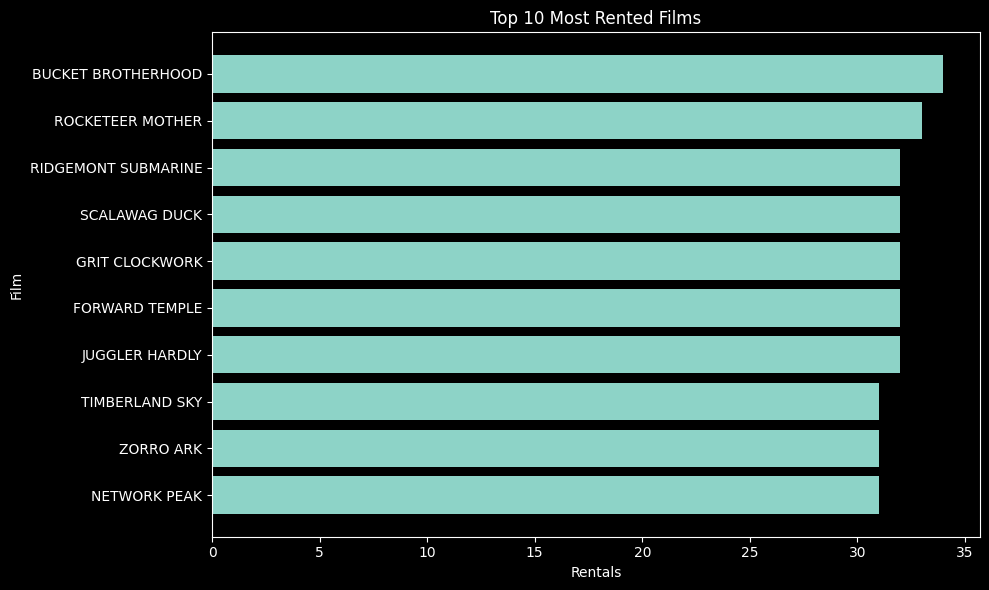

In [34]:
most_rented_films = pd.read_sql(
    """
    SELECT f.title AS film, f.category_name AS category, COUNT(r.rental_id) AS rentals
    FROM fact_rental r
    JOIN dim_film f ON r.film_key = f.film_key
    GROUP BY f.title, f.category_name
    ORDER BY rentals DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(most_rented_films)

plt.figure(figsize=(10, 6))
plt.barh(most_rented_films["film"], most_rented_films["rentals"])
plt.xlabel("Rentals")
plt.ylabel("Film")
plt.title("Top 10 Most Rented Films")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 2: Highest Revenue Films

Which films generate the highest revenue?

,film,category,total_revenue
0,TELEGRAPH VOYAGE,Music,231.73
1,WIFE TURN,Documentary,223.69
2,ZORRO ARK,Comedy,214.69
3,GOODFELLAS SALUTE,Sci-Fi,209.69
4,SATURDAY LAMBS,Sports,204.72
5,TITANS JERK,Sci-Fi,201.71
6,TORQUE BOUND,Drama,198.72
7,HARRY IDAHO,Drama,195.70
8,INNOCENT USUAL,Foreign,191.74
9,HUSTLER PARTY,Comedy,190.78


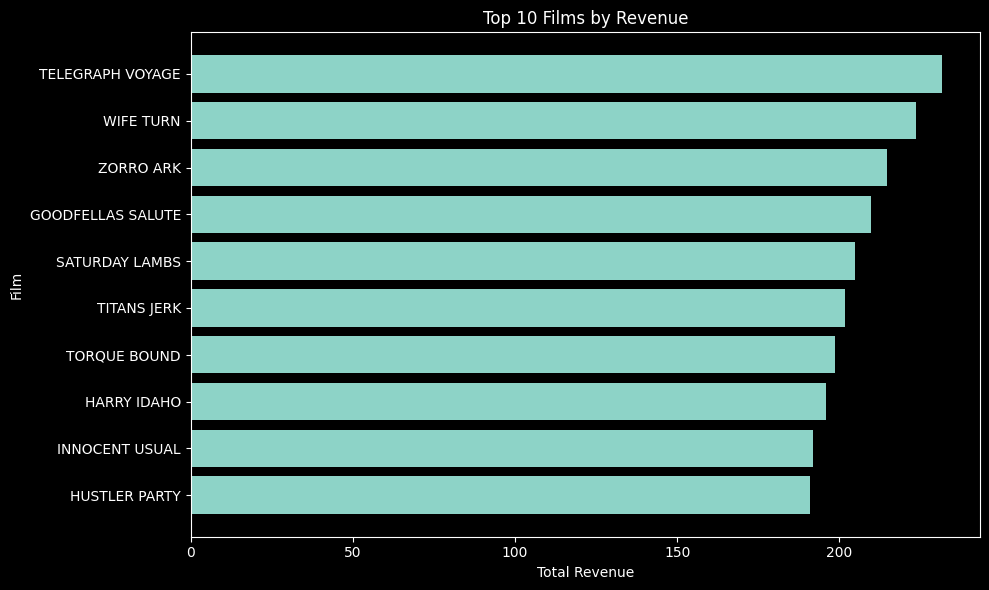

In [35]:
highest_revenue_films = pd.read_sql(
    """
    SELECT f.title AS film, f.category_name AS category, ROUND(SUM(p.revenue), 2) AS total_revenue
    FROM fact_payment p
    JOIN dim_film f ON p.film_key = f.film_key
    GROUP BY f.title, f.category_name
    ORDER BY total_revenue DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(highest_revenue_films)

plt.figure(figsize=(10, 6))
plt.barh(highest_revenue_films["film"], highest_revenue_films["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Film")
plt.title("Top 10 Films by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 3: Most Popular Film Categories

Which film categories are most popular?

,category,rentals
0,Sports,1179
1,Animation,1166
2,Action,1112
3,Sci-Fi,1101
4,Family,1096
5,Drama,1060
6,Documentary,1050
7,Foreign,1033
8,Games,969
9,Children,945


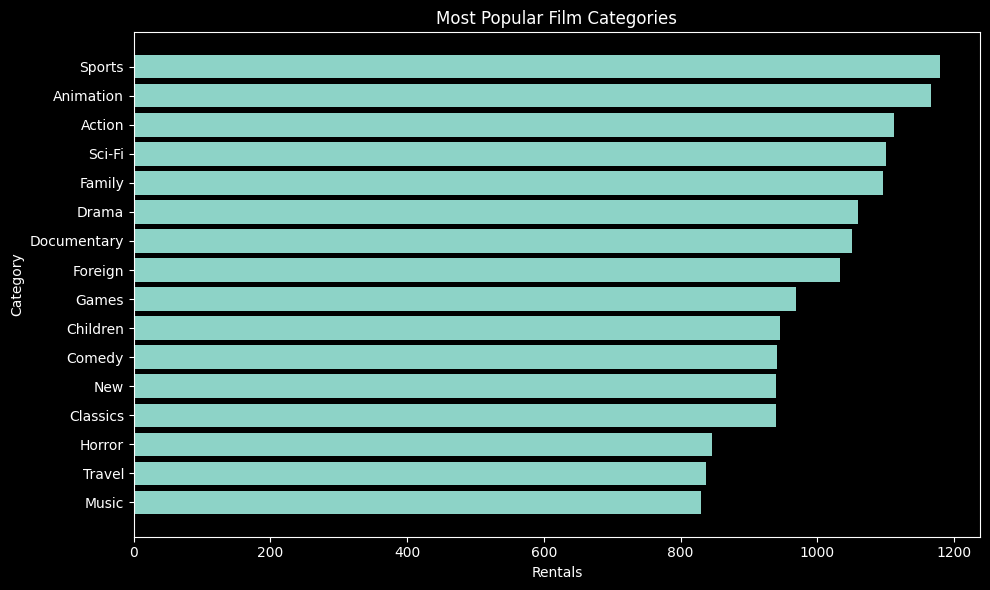

In [36]:
popular_categories = pd.read_sql(
    """
    SELECT f.category_name AS category, COUNT(r.rental_id) AS rentals
    FROM fact_rental r
    JOIN dim_film f ON r.film_key = f.film_key
    GROUP BY f.category_name
    ORDER BY rentals DESC;
    """,
    con=warehouse_engine
)

display(popular_categories)

plt.figure(figsize=(10, 6))
plt.barh(popular_categories["category"], popular_categories["rentals"])
plt.xlabel("Rentals")
plt.ylabel("Category")
plt.title("Most Popular Film Categories")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 4: Rentals by Store

Which stores generate the highest number of rentals?

,store_id,city,country,rentals
0,2,Woodridge,Australia,8121
1,1,Lethbridge,Canada,7923


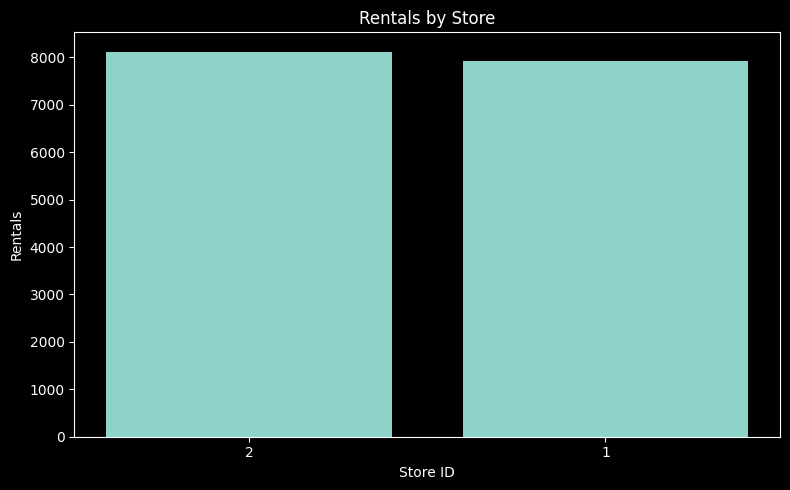

In [37]:
rentals_by_store = pd.read_sql(
    """
    SELECT s.store_id, s.city, s.country, COUNT(r.rental_id) AS rentals
    FROM fact_rental r
    JOIN dim_store s ON r.store_key = s.store_key
    GROUP BY s.store_id, s.city, s.country
    ORDER BY rentals DESC;
    """,
    con=warehouse_engine
)

display(rentals_by_store)

plt.figure(figsize=(8, 5))
plt.bar(rentals_by_store["store_id"].astype(str), rentals_by_store["rentals"])
plt.xlabel("Store ID")
plt.ylabel("Rentals")
plt.title("Rentals by Store")
plt.tight_layout()
plt.show()

## Answer 5: Revenue by Store

Which stores generate the highest revenue?

,store_id,city,country,total_revenue
0,2,Woodridge,Australia,33726.77
1,1,Lethbridge,Canada,33679.79


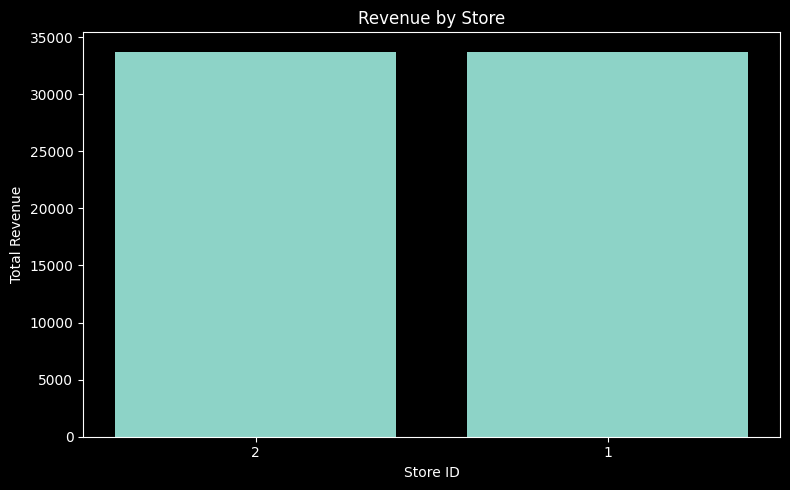

In [38]:
revenue_by_store = pd.read_sql(
    """
    SELECT s.store_id, s.city, s.country, ROUND(SUM(p.revenue), 2) AS total_revenue
    FROM fact_payment p
    JOIN dim_store s ON p.store_key = s.store_key
    GROUP BY s.store_id, s.city, s.country
    ORDER BY total_revenue DESC;
    """,
    con=warehouse_engine
)

display(revenue_by_store)

plt.figure(figsize=(8, 5))
plt.bar(revenue_by_store["store_id"].astype(str), revenue_by_store["total_revenue"])
plt.xlabel("Store ID")
plt.ylabel("Total Revenue")
plt.title("Revenue by Store")
plt.tight_layout()
plt.show()

## Answer 6: Customers with Most Rentals

Which customers rent the most films?

In [39]:
top_rental_customers = pd.read_sql(
    """
    SELECT c.full_name AS customer, c.city, c.country, COUNT(r.rental_id) AS rentals
    FROM fact_rental r
    JOIN dim_customer c ON r.customer_key = c.customer_key
    GROUP BY c.full_name, c.city, c.country
    ORDER BY rentals DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(top_rental_customers)

,customer,city,country,rentals
0,ELEANOR HUNT,Saint-Denis,RÃ©union,46
1,KARL SEAL,Cape Coral,United States,45
2,CLARA SHAW,MolodetÅ¡no,Belarus,42
3,MARCIA DEAN,Tanza,Philippines,42
4,TAMMY SANDERS,Changhwa,Taiwan,41
5,WESLEY BULL,Ourense (Orense),Spain,40
6,SUE PETERS,Changzhou,China,40
7,RHONDA KENNEDY,Apeldoorn,Netherlands,39
8,MARION SNYDER,Santa Brbara dOeste,Brazil,39
9,TIM CARY,Bijapur,India,39


## Answer 7: Top Customers by Revenue

Which customers generate the highest revenue?

,customer,city,country,total_spent
0,KARL SEAL,Cape Coral,United States,221.55
1,ELEANOR HUNT,Saint-Denis,RÃ©union,216.54
2,CLARA SHAW,MolodetÅ¡no,Belarus,195.58
3,RHONDA KENNEDY,Apeldoorn,Netherlands,194.61
4,MARION SNYDER,Santa Brbara dOeste,Brazil,194.61
5,TOMMY COLLAZO,Qomsheh,Iran,186.62
6,WESLEY BULL,Ourense (Orense),Spain,177.60
7,TIM CARY,Bijapur,India,175.61
8,MARCIA DEAN,Tanza,Philippines,175.58
9,ANA BRADLEY,Memphis,United States,174.66


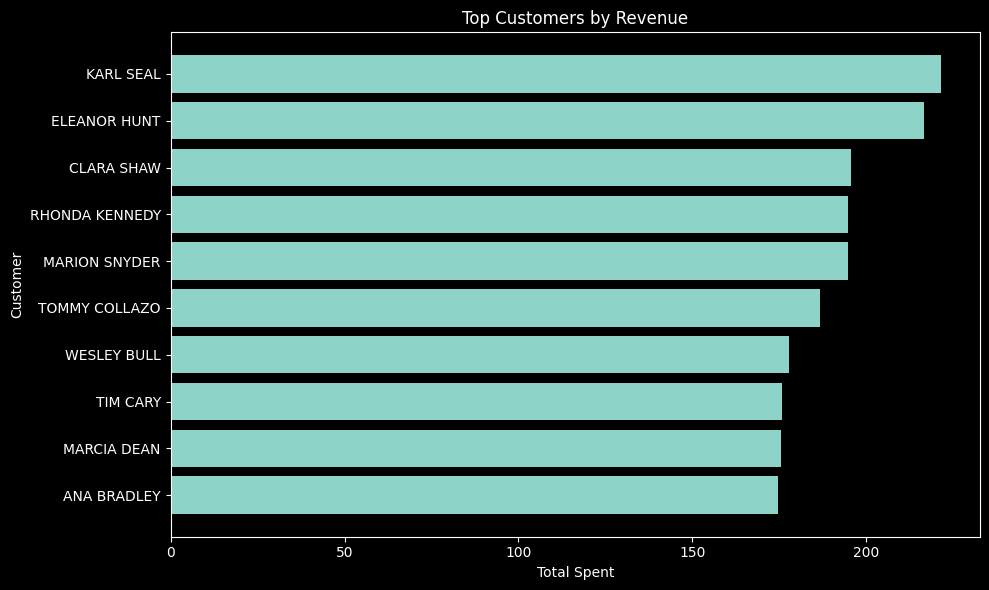

In [40]:
top_revenue_customers = pd.read_sql(
    """
    SELECT c.full_name AS customer, c.city, c.country, ROUND(SUM(p.revenue), 2) AS total_spent
    FROM fact_payment p
    JOIN dim_customer c ON p.customer_key = c.customer_key
    GROUP BY c.full_name, c.city, c.country
    ORDER BY total_spent DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(top_revenue_customers)

plt.figure(figsize=(10, 6))
plt.barh(top_revenue_customers["customer"], top_revenue_customers["total_spent"])
plt.xlabel("Total Spent")
plt.ylabel("Customer")
plt.title("Top Customers by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 8: Rental Activity Over Time

How does rental activity change over time?

,year,month,month_name,rentals,year_month
0,2005,5,May,1156,2005-05
1,2005,6,June,2311,2005-06
2,2005,7,July,6709,2005-07
3,2005,8,August,5686,2005-08
4,2006,2,February,182,2006-02


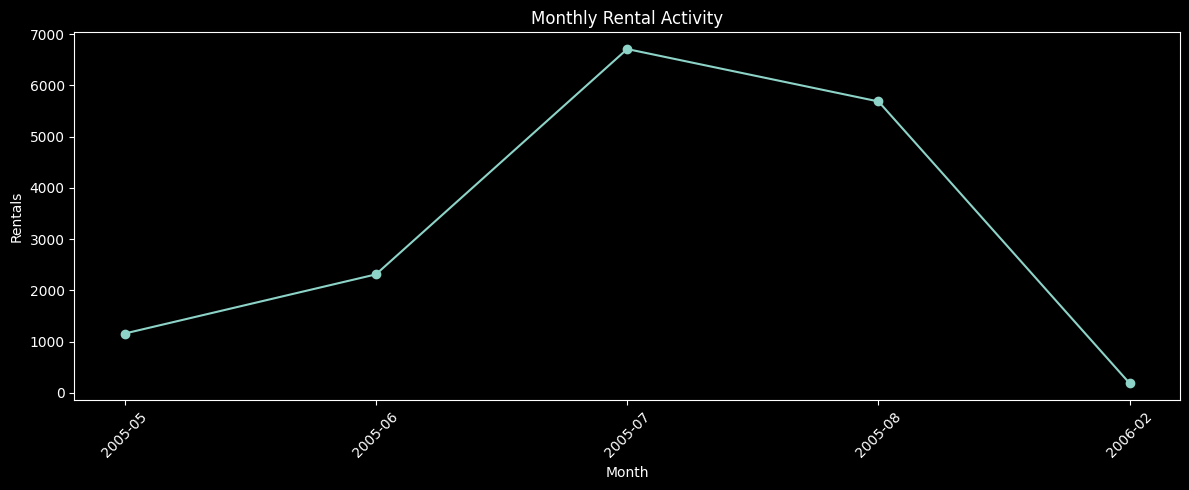

In [41]:
monthly_rentals = pd.read_sql(
    """
    SELECT d.year, d.month, d.month_name, COUNT(r.rental_id) AS rentals
    FROM fact_rental r
    JOIN dim_date d ON r.rental_date_key = d.date_key
    GROUP BY d.year, d.month, d.month_name
    ORDER BY d.year, d.month;
    """,
    con=warehouse_engine
)

monthly_rentals["year_month"] = monthly_rentals["year"].astype(str) + "-" + monthly_rentals["month"].astype(str).str.zfill(2)

display(monthly_rentals)

plt.figure(figsize=(12, 5))
plt.plot(monthly_rentals["year_month"], monthly_rentals["rentals"], marker="o")
plt.xlabel("Month")
plt.ylabel("Rentals")
plt.title("Monthly Rental Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Answer 9: Revenue by Month, Quarter, and Year

How does revenue change by month, quarter, or year?

,year,quarter,month,month_name,revenue,year_month
0,2005,2,5,May,4823.44,2005-05
1,2005,2,6,June,9629.89,2005-06
2,2005,3,7,July,28368.91,2005-07
3,2005,3,8,August,24070.14,2005-08
4,2006,1,2,February,514.18,2006-02


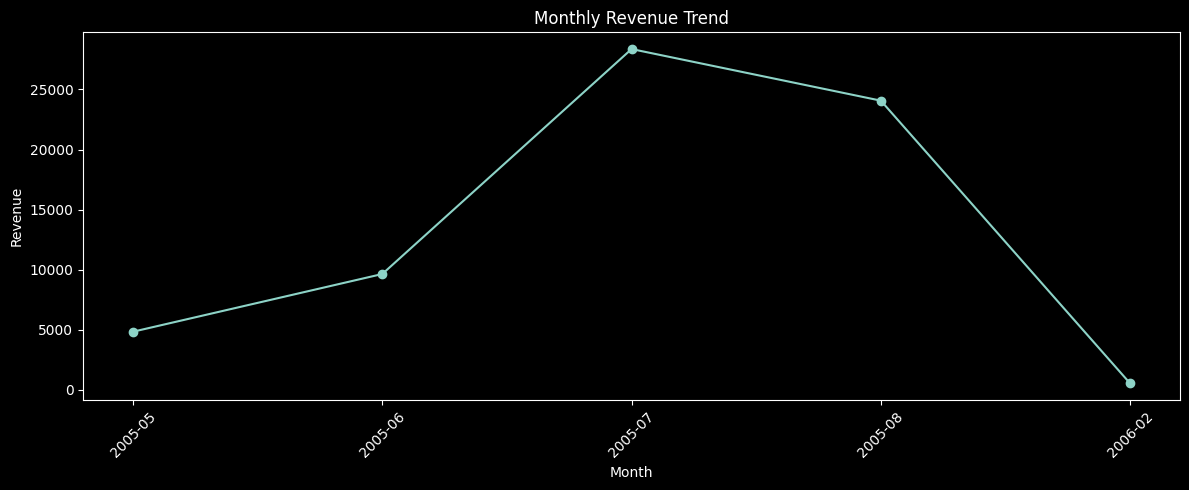

In [42]:
revenue_time = pd.read_sql(
    """
    SELECT d.year, d.quarter, d.month, d.month_name, ROUND(SUM(p.revenue), 2) AS revenue
    FROM fact_payment p
    JOIN dim_date d ON p.payment_date_key = d.date_key
    GROUP BY d.year, d.quarter, d.month, d.month_name
    ORDER BY d.year, d.month;
    """,
    con=warehouse_engine
)

revenue_time["year_month"] = revenue_time["year"].astype(str) + "-" + revenue_time["month"].astype(str).str.zfill(2)

display(revenue_time)

plt.figure(figsize=(12, 5))
plt.plot(revenue_time["year_month"], revenue_time["revenue"], marker="o")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Answer 10: Staff Performance

Which staff members process the highest number of rentals or payments?

,staff_member,rentals_processed,payments_processed,total_revenue
0,Jon Stephens,8004,7990,2.715282e+08
1,Mike Hillyer,8040,8054,2.691993e+08


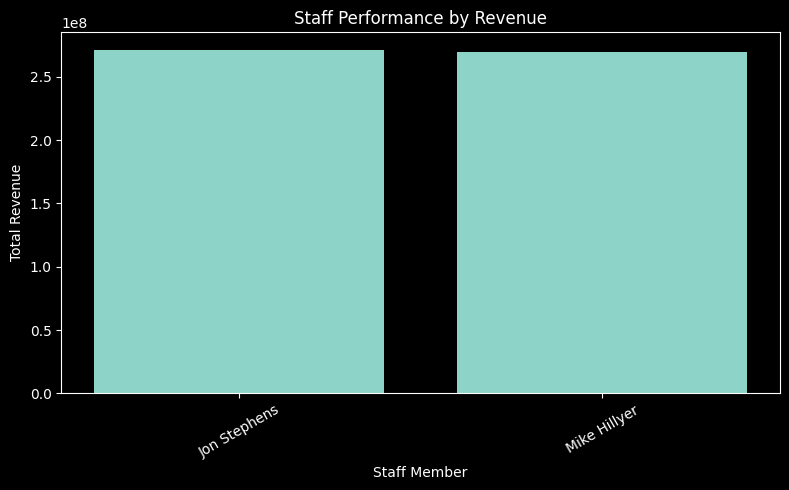

In [43]:
staff_performance = pd.read_sql(
    """
    SELECT s.full_name AS staff_member,
           COUNT(DISTINCT r.rental_id) AS rentals_processed,
           COUNT(DISTINCT p.payment_id) AS payments_processed,
           ROUND(SUM(p.revenue), 2) AS total_revenue
    FROM dim_staff s
    LEFT JOIN fact_rental r ON s.staff_key = r.staff_key
    LEFT JOIN fact_payment p ON s.staff_key = p.staff_key
    GROUP BY s.full_name
    ORDER BY total_revenue DESC;
    """,
    con=warehouse_engine
)

display(staff_performance)

plt.figure(figsize=(8, 5))
plt.bar(staff_performance["staff_member"], staff_performance["total_revenue"])
plt.xlabel("Staff Member")
plt.ylabel("Total Revenue")
plt.title("Staff Performance by Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Answer 11 and 15: Customer Activity by Location

Which cities or countries generate the highest customer activity, and what are the most active customer locations?

,city,country,rental_count,total_revenue
0,Aurora,United States,50,198.50
1,London,United Kingdom,48,180.52
2,Saint-Denis,RÃ©union,46,216.54
3,Cape Coral,United States,45,221.55
4,Tanza,Philippines,42,175.58
5,MolodetÅ¡no,Belarus,42,195.58
6,Changhwa,Taiwan,41,155.59
7,Changzhou,China,40,154.60
8,Ourense (Orense),Spain,40,177.60
9,Apeldoorn,Netherlands,39,194.61


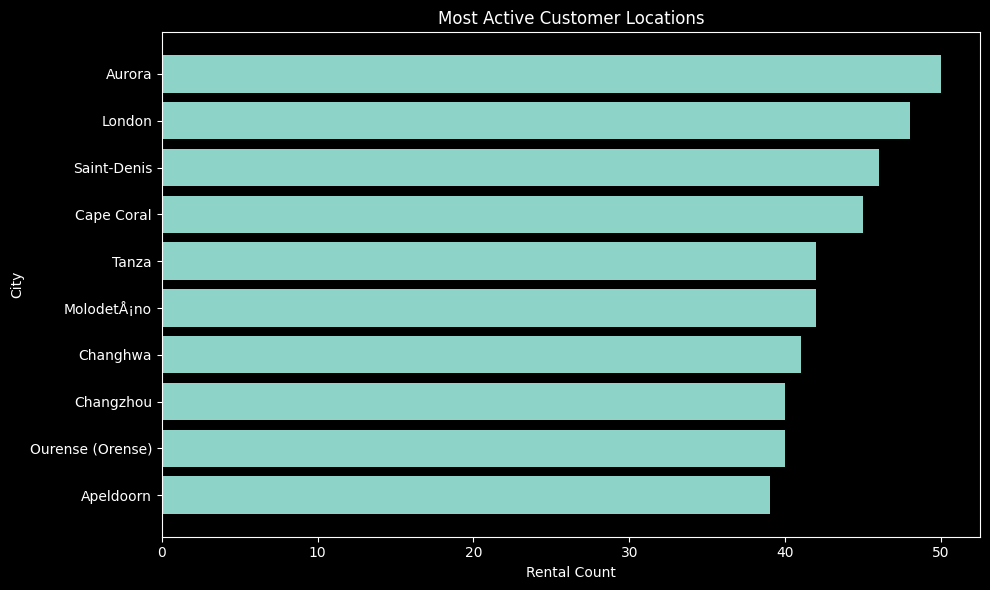

In [44]:
customer_locations = pd.read_sql(
    """
    SELECT c.city, c.country, COUNT(r.rental_id) AS rental_count, ROUND(SUM(p.revenue), 2) AS total_revenue
    FROM fact_rental r
    JOIN dim_customer c ON r.customer_key = c.customer_key
    LEFT JOIN fact_payment p ON r.rental_id = p.rental_id
    GROUP BY c.city, c.country
    ORDER BY rental_count DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(customer_locations)

plt.figure(figsize=(10, 6))
plt.barh(customer_locations["city"], customer_locations["rental_count"])
plt.xlabel("Rental Count")
plt.ylabel("City")
plt.title("Most Active Customer Locations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 12: Average Rental Duration by Category

What is the average rental duration for different films or categories?

,category,average_actual_duration_days,average_expected_duration_days
0,Sports,4.70,4.74
1,Games,4.69,5.01
2,Comedy,4.66,4.80
3,Sci-Fi,4.58,4.78
4,Music,4.57,5.26
5,Horror,4.56,4.93
6,Documentary,4.55,4.65
7,Family,4.54,5.16
8,New,4.53,4.50
9,Action,4.52,4.94


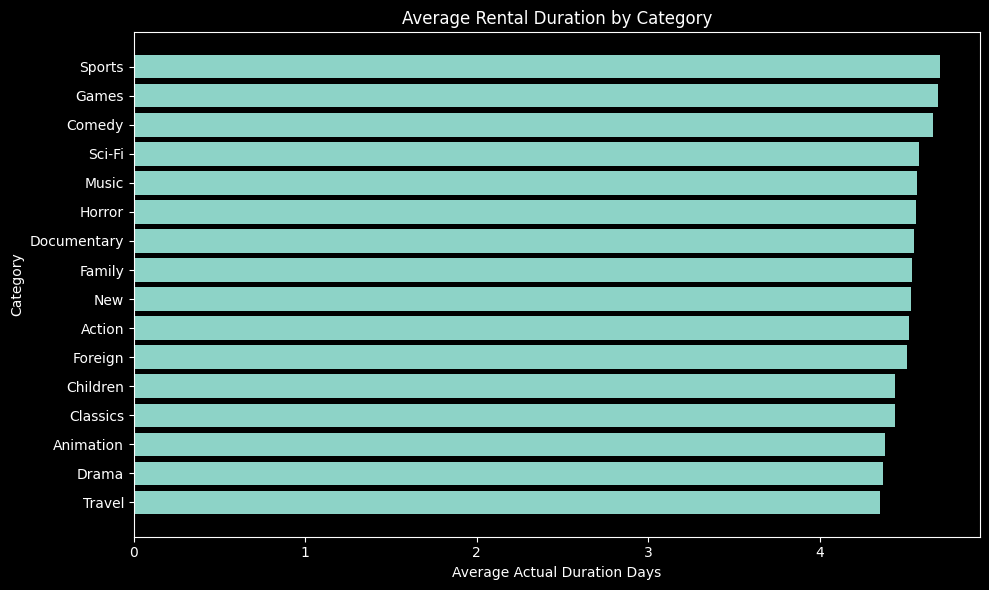

In [45]:
avg_duration_by_category = pd.read_sql(
    """
    SELECT f.category_name AS category,
           ROUND(AVG(r.actual_rental_duration_days), 2) AS average_actual_duration_days,
           ROUND(AVG(r.expected_rental_duration_days), 2) AS average_expected_duration_days
    FROM fact_rental r
    JOIN dim_film f ON r.film_key = f.film_key
    WHERE r.actual_rental_duration_days IS NOT NULL
    GROUP BY f.category_name
    ORDER BY average_actual_duration_days DESC;
    """,
    con=warehouse_engine
)

display(avg_duration_by_category)

plt.figure(figsize=(10, 6))
plt.barh(avg_duration_by_category["category"], avg_duration_by_category["average_actual_duration_days"])
plt.xlabel("Average Actual Duration Days")
plt.ylabel("Category")
plt.title("Average Rental Duration by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 13: Late Returns

Which films are returned late most often?

,film,category,late_returns,average_late_days
0,RIDGEMONT SUBMARINE,New,24,3.63
1,BUTTERFLY CHOCOLAT,New,23,3.35
2,TELEGRAPH VOYAGE,Music,22,3.77
3,TIMBERLAND SKY,Classics,21,3.90
4,CHANCE RESURRECTION,Sports,20,2.45
5,GRIT CLOCKWORK,Games,20,3.40
6,ROCKETEER MOTHER,Foreign,20,3.75
7,ENGLISH BULWORTH,Sci-Fi,20,3.05
8,SATURDAY LAMBS,Sports,19,2.84
9,PRINCESS GIANT,Documentary,19,2.95


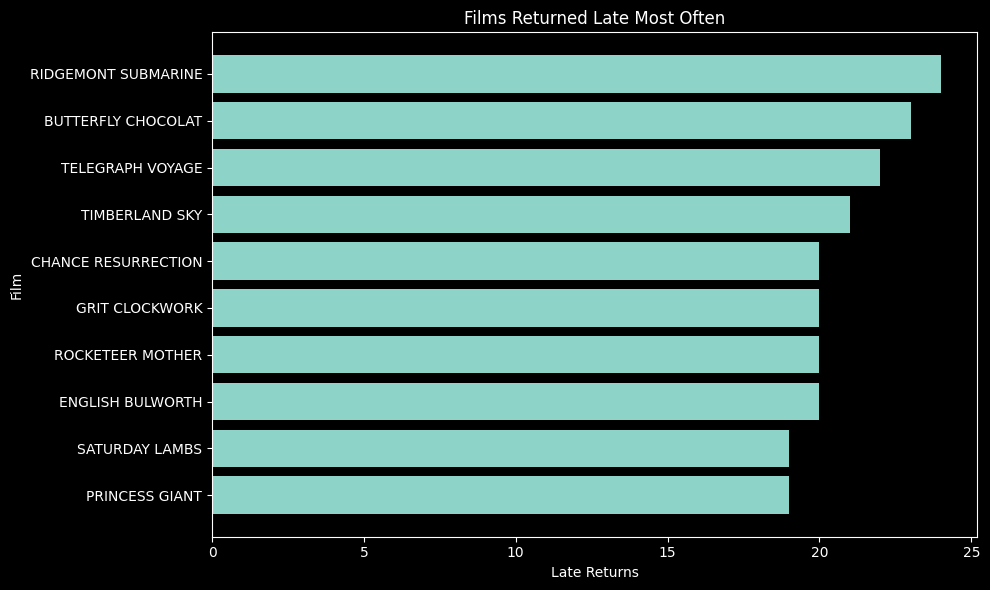

In [46]:
late_return_films = pd.read_sql(
    """
    SELECT f.title AS film, f.category_name AS category,
           COUNT(r.rental_id) AS late_returns,
           ROUND(AVG(r.late_days), 2) AS average_late_days
    FROM fact_rental r
    JOIN dim_film f ON r.film_key = f.film_key
    WHERE r.is_late_return = 1
    GROUP BY f.title, f.category_name
    ORDER BY late_returns DESC
    LIMIT 10;
    """,
    con=warehouse_engine
)

display(late_return_films)

plt.figure(figsize=(10, 6))
plt.barh(late_return_films["film"], late_return_films["late_returns"])
plt.xlabel("Late Returns")
plt.ylabel("Film")
plt.title("Films Returned Late Most Often")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Answer 14: Store Performance by Location

How does store performance differ by location?

In [47]:
store_location_performance = pd.read_sql(
    """
    SELECT s.store_id, s.city, s.country,
           COUNT(DISTINCT r.rental_id) AS rental_count,
           ROUND(SUM(p.revenue), 2) AS total_revenue
    FROM dim_store s
    LEFT JOIN fact_rental r ON s.store_key = r.store_key
    LEFT JOIN fact_payment p ON s.store_key = p.store_key
    GROUP BY s.store_id, s.city, s.country
    ORDER BY total_revenue DESC;
    """,
    con=warehouse_engine
)

display(store_location_performance)

,store_id,city,country,rental_count,total_revenue
0,2,Woodridge,Australia,8121,2.738951e+08
1,1,Lethbridge,Canada,7923,2.668450e+08


## Conclusion

This notebook builds a simple and complete data warehouse pipeline for the movie rental OLTP database.

It includes:

- Dimensional model
- EDA
- ETL
- Data contract and validation
- Load verification
- Analytical answers
- Visualizations

The warehouse supports business analysis for films, categories, customers, stores, staff, locations, rentals, revenue, late returns, and time trends.
